# **Deep Learning Portfolio Opdracht 3: Transforming Fashion**
## Team: HutsGroep
* Eduard Bunatyan - eduardbunatyan - 24056707
* Gianni Dochez Kok - giannidk - 23037938
* Gillian van der Voort van der Kleij - gillianvdvoort - 24160873
* Wouter Kox - wouterkox19 - 24135879

GitHub: https://github.com/gianni-dk/Transforming-Fashion

## Inleiding

In dit notebook werken we drie deep learning-taken op modefoto's uit en knopen we deze aan elkaar tot één pipeline. We bouwen achter elkaar een objectdetectiemodel (YOLOv8), een image captioning-model (Vision-Encoder-Decoder) en een tekst-naar-beeld generatie via Latent Diffusion. Tot slot plakken we de eerste twee modellen aan elkaar in een kleine app die kledingstukken op een foto herkent en er meteen een beschrijving bij schrijft.

We lopen het proces stap voor stap door. Eerst doen we een EDA om te zien wat er in de dataset zit. Daarna fine-tunen we de modellen los van elkaar, lichten we onze keuzes kort toe en evalueren we de resultaten op mAP en BLEU.

## Setup & Data Inladen

Allereerst koppelen we Google Drive om bij de afbeeldingen en de YOLO-labels te kunnen. De caption-dataset trekken we rechtstreeks binnen via HuggingFace.

In [1]:
# Standaard libraries
import os
import random
import warnings
import glob
from collections import Counter

# Data manipulatie en visualisatie
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import seaborn as sns

# Deep learning frameworks
import torch
from torch.utils.data import Dataset, DataLoader

# Waarschuwingen uitzetten voor een schoner notebook
warnings.filterwarnings("ignore")

# Seeds instellen zodat we steeds dezelfde resultaten krijgen bij het runnen
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

# Mooiere styling voor de grafieken
sns.set_style("whitegrid")

In [2]:
# Benodigde externe packages installeren (Colab)
!pip install -q ultralytics datasets transformers diffusers accelerate sacrebleu evaluate

In [3]:
# Google Drive koppelen (nodig voor de schoolomgeving)
from google.colab import drive
drive.mount('/content/drive')

# Paden instellen naar de juiste mappen en bestanden
base_dir = '/content/drive/MyDrive/DeepLearning_fashion/transforming-fashion-2026'
dataset_dir = f'{base_dir}/Dataset'

train_images_dir = f'{dataset_dir}/Train/images'
train_labels_dir = f'{dataset_dir}/Train/labels'
test_images_dir = f'{dataset_dir}/Test/images'
data_yaml_path = f'{base_dir}/data.yaml'

# Klassennamen volgens de eisen van de opdracht
CLASS_NAMES = ['sunglasses', 'hat', 'jacket', 'shirt', 'pants',
               'shorts', 'skirt', 'dress', 'bag', 'shoe']

# Even checken hoeveel data we daadwerkelijk hebben
print(f"Aantal train images: {len(os.listdir(train_images_dir))}")
print(f"Aantal test images : {len(os.listdir(test_images_dir))}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Aantal train images: 2145
Aantal test images : 537


In [4]:
# HuggingFace captioning dataset inladen
from datasets import load_dataset

caption_ds = load_dataset("tomytjandra/h-and-m-fashion-caption-12k", split="train")
print(caption_ds)

# De eerste caption bekijken om een idee te krijgen van de teksten
print("Voorbeeld caption:", caption_ds[0]['text'])

Dataset({
    features: ['text', 'image'],
    num_rows: 12437
})
Voorbeeld caption: solid dark blue fitted top in soft stretch jersey with a wide neckline and long sleeves


## 1. Opdracht 1: Exploratieve Data Analyse (EDA)

Voordat we modellen gaan trainen, brengen we eerst de dataset in kaart. We plotten een paar voorbeelden met bounding-boxes om te checken of de labels netjes op de juiste plek staan. Daarna kijken we naar de klasseverdeling van de YOLO-dataset, want een scheve verdeling werkt straks door in de recall van zeldzame klassen. Tot slot kijken we naar de meest voorkomende woorden in de caption-dataset, om te bepalen of de YOLO-klassen en de captions inhoudelijk op elkaar aansluiten.

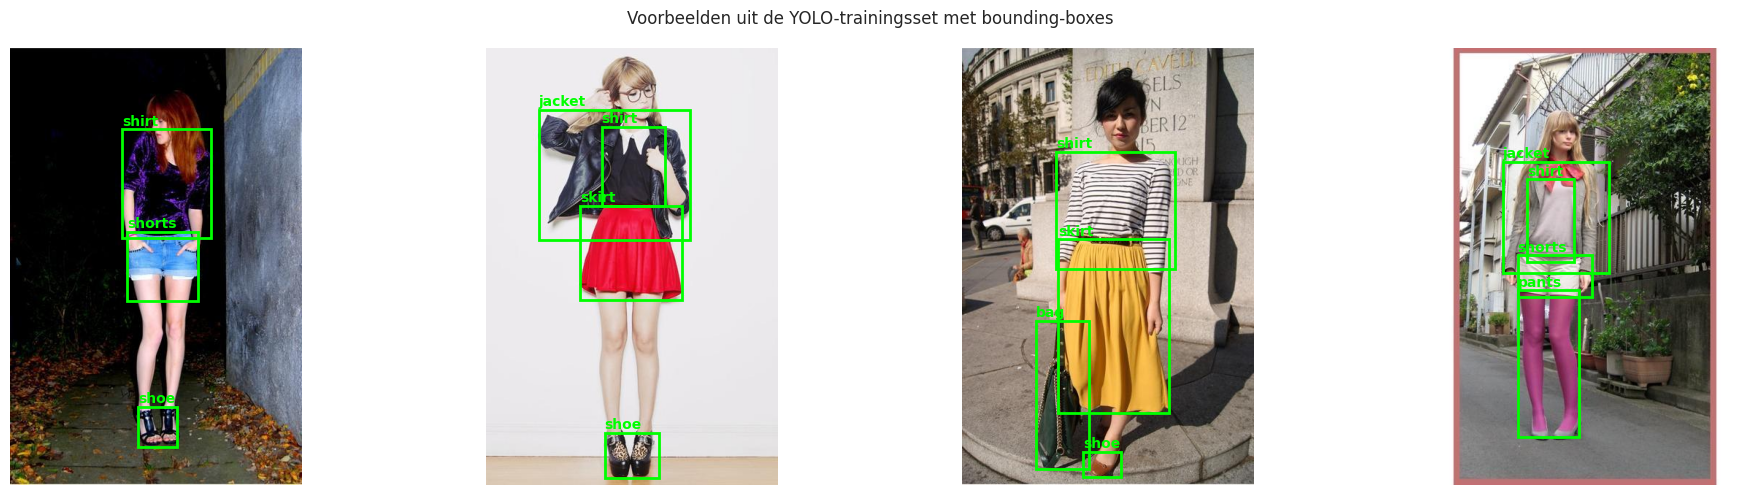

In [5]:
def lees_yolo_labels(label_path):
    # Leest een YOLO-label bestand in en geeft een lijst van (class_id, x, y, w, h) terug
    boxes = []
    if not os.path.exists(label_path):
        return boxes
    with open(label_path, 'r') as f:
        for line in f.readlines():
            parts = line.strip().split()
            if len(parts) == 5:
                cls, x, y, w, h = parts
                boxes.append((int(cls), float(x), float(y), float(w), float(h)))
    return boxes

def plot_image_met_boxes(image_path, label_path, class_names, ax=None):
    # Plot een afbeelding met bijhorende YOLO bounding-boxes
    img = Image.open(image_path).convert("RGB")
    W, H = img.size
    if ax is None:
        fig, ax = plt.subplots(1, figsize=(6, 6))
    ax.imshow(img)
    for cls, x, y, w, h in lees_yolo_labels(label_path):
        x1 = (x - w / 2) * W
        y1 = (y - h / 2) * H
        rect = patches.Rectangle((x1, y1), w * W, h * H,
                                 linewidth=2, edgecolor='lime', facecolor='none')
        ax.add_patch(rect)
        ax.text(x1, y1 - 5, class_names[cls], color='lime',
                fontsize=10, weight='bold')
    ax.axis('off')

# Een paar willekeurige train-afbeeldingen met boxes plotten
sample_imgs = random.sample(os.listdir(train_images_dir), 4)
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, img_name in zip(axes, sample_imgs):
    img_path = os.path.join(train_images_dir, img_name)
    label_path = os.path.join(train_labels_dir, img_name.rsplit('.', 1)[0] + '.txt')
    plot_image_met_boxes(img_path, label_path, CLASS_NAMES, ax=ax)
plt.suptitle("Voorbeelden uit de YOLO-trainingsset met bounding-boxes")
plt.tight_layout()
plt.show()

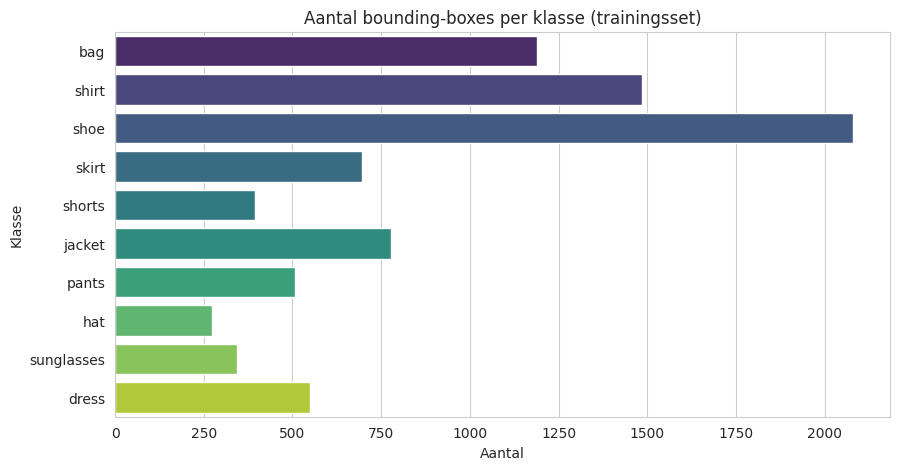

Counter({'shoe': 2081, 'shirt': 1486, 'bag': 1188, 'jacket': 777, 'skirt': 697, 'dress': 550, 'pants': 508, 'shorts': 395, 'sunglasses': 343, 'hat': 273})


In [6]:
# Klassenverdeling van de YOLO-dataset analyseren
class_counter = Counter()
for label_file in glob.glob(f'{train_labels_dir}/*.txt'):
    for cls, *_ in lees_yolo_labels(label_file):
        class_counter[CLASS_NAMES[cls]] += 1

plt.figure(figsize=(10, 5))
sns.barplot(x=list(class_counter.values()),
            y=list(class_counter.keys()), palette='viridis')
plt.title("Aantal bounding-boxes per klasse (trainingsset)")
plt.xlabel("Aantal")
plt.ylabel("Klasse")
plt.show()
print(class_counter)

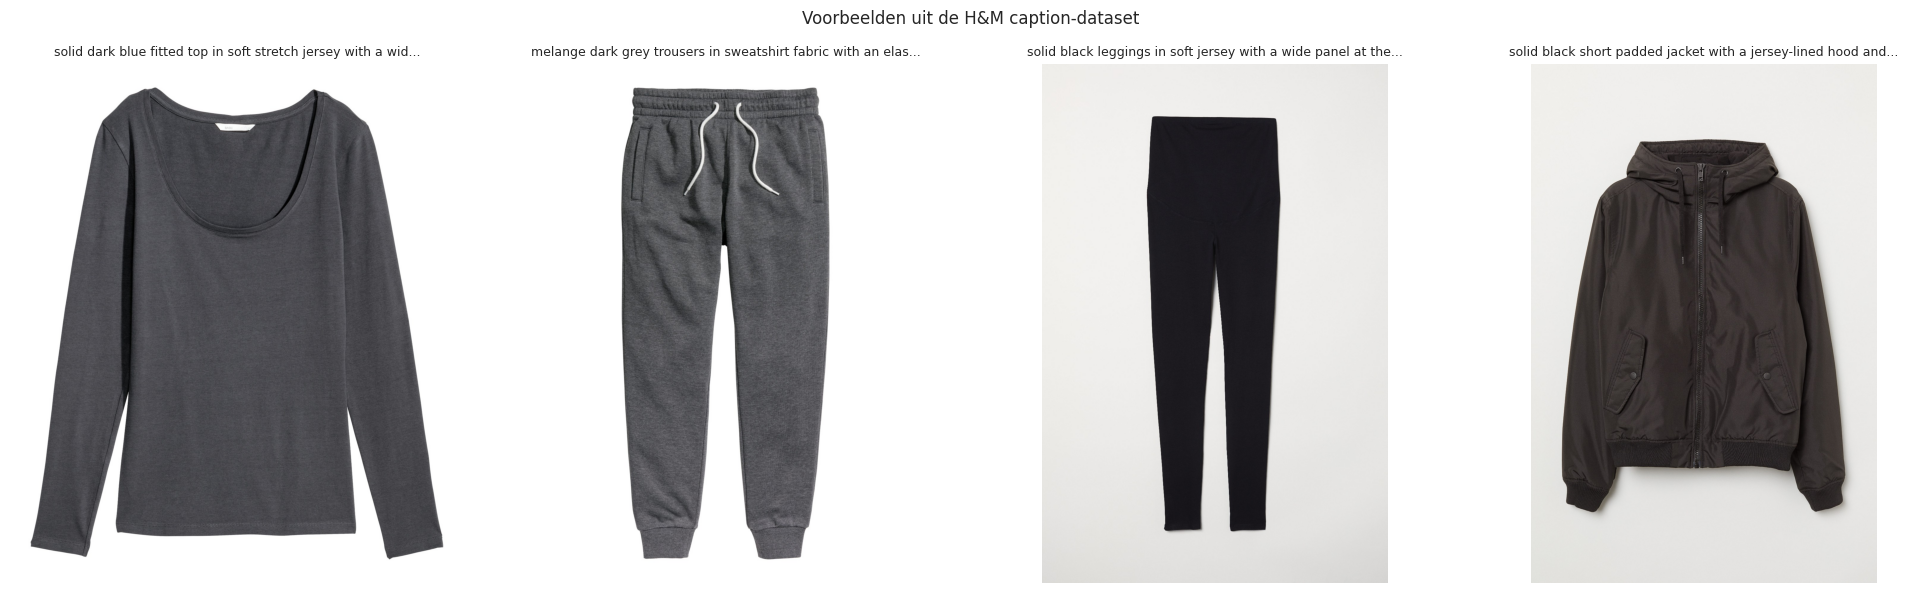

In [7]:
# Caption-dataset: een paar voorbeelden tonen om een idee te krijgen van de teksten
fig, axes = plt.subplots(1, 4, figsize=(20, 6))
for i, ax in enumerate(axes):
    sample = caption_ds[i]
    ax.imshow(sample['image'])
    ax.set_title(sample['text'][:60] + "...", fontsize=9)
    ax.axis('off')
plt.suptitle("Voorbeelden uit de H&M caption-dataset")
plt.tight_layout()
plt.show()

In [8]:
# Meest voorkomende woorden in de captions berekenen
alle_woorden = ' '.join([c.lower() for c in caption_ds['text']]).split()
top_woorden = Counter(alle_woorden).most_common(15)
print("Top 15 woorden in captions:", top_woorden)

# Checken of de objecten uit YOLO ook daadwerkelijk voorkomen in de teksten
gemeenschappelijk = [cls for cls in CLASS_NAMES if any(cls in c.lower() for c in caption_ds['text'])]
print("Gemeenschappelijke items (YOLO doorsnede Captions):", gemeenschappelijk)

Top 15 woorden in captions: [('a', 21431), ('and', 19752), ('with', 19069), ('the', 17791), ('in', 13837), ('at', 11041), ('solid', 6805), ('sleeves', 5387), ('front', 4953), ('back', 4750), ('black', 4157), ('waist', 4150), ('pockets', 3938), ('top', 3910), ('cuffs', 3740)]
Gemeenschappelijke items (YOLO doorsnede Captions): ['hat', 'jacket', 'shirt', 'pants', 'shorts', 'skirt', 'dress', 'bag']


### Bevindingen EDA

De dataset bestaat uit 2145 trainingsafbeeldingen en 537 testafbeeldingen. Uit de barplot blijkt een duidelijke onbalans:

- **Oververtegenwoordigd:** `shoe` (2081), `shirt` (1486) en `bag` (1188) komen het vaakst voor. Dat is logisch, want op vrijwel elke modefoto staan schoenen en een bovenstuk.
- **Ondervertegenwoordigd:** `hat` (273), `sunglasses` (343) en `shorts` (395) komen aanzienlijk minder voor. We verwachten dat YOLO deze accessoires lastiger gaat detecteren, met een lagere recall als gevolg.
- **Visuele inspectie:** De voorbeeldfoto's zijn overwegend frontale outfit-shots waarop personen volledig in beeld staan. De bounding-boxes zitten op de juiste plek.

Bij de caption-dataset zien we dat de teksten vooral kleur-, materiaal- en stijlbeschrijvingen bevatten. De top-15 woorden zijn voornamelijk verbindingswoorden (`a`, `and`, `with`, `the`). Belangrijker: van de tien YOLO-klassen komen er negen ook letterlijk voor in de captions (alleen `sunglasses` ontbreekt als losse term). Hierdoor kunnen we de twee datasets in Opdracht 5 zonder problemen aan elkaar knopen.

## 2. Opdracht 2: Objectdetectie met YOLO

Voor de objectdetectie gebruiken we het YOLO-algoritme (You Only Look Once). YOLO verdeelt de afbeelding in één forward pass in een vast grid, in tegenstelling tot oudere detectiemodellen die meerdere iteraties of region proposals nodig hebben.

**Waarom YOLO en geen standaard CNN?** Een standaard CNN is een classifier: die geeft per afbeelding één label terug. Wij willen juist meerdere objecten tegelijk, inclusief positie en grootte. YOLO lost dit op door bovenop een CNN-backbone (die de visuele features eruit haalt) een detectiekop te zetten die per gridcel direct de bounding-box coördinaten, een confidence-score en de klassekansen voorspelt. Het resultaat: één model, één forward pass, en zowel klasse als locatie als output. Dat is sneller en geschikter dan een standaard CNN voor onze taak.

**Architectuur en werking.** De output van een YOLO-model is een tensor. Per gridcel voorspelt het model meerdere bounding boxes met (x, y, w, h), een confidence-score en de kansen voor alle klassen. Doordat objecten vaak meerdere boxen genereren, past YOLO Non-Max Suppression (NMS) toe: overlappende boxen van hetzelfde object worden gefilterd op basis van hun confidence.

**Transfer Learning.** Omdat onze dataset met 2145 afbeeldingen aan de kleine kant is, gebruiken we transfer learning. We starten met de gewichten van `yolov8n.pt`, voorgetraind op COCO. De backbone bevat hierdoor al sterke filters voor randen, vormen en texturen. Wij fine-tunen alleen nog op onze tien kledingklassen. We trainen met SGD en een learning rate van 0.01.

**Evaluatie (IoU en mAP).** We evalueren met de Mean Average Precision (mAP). Deze maat is gebaseerd op de Intersection over Union (IoU): het oppervlak van de overlap tussen de voorspelde en de echte box, gedeeld door het oppervlak van de vereniging. IoU = 1.0 betekent een perfecte fit. mAP@0.5 is de gemiddelde precisie over alle klassen bij een IoU-drempel van 0.5.

In [10]:
# YOLO heeft een configuratiebestand (YAML) nodig om de exacte paden naar de datasets te vinden.
# We genereren deze hier dynamisch om te garanderen dat het notebook altijd reproduceerbaar is,
# ongeacht de lokale Drive-structuur van de gebruiker.

yaml_config = f"""
train: {train_images_dir}
val: {train_images_dir}
test: {test_images_dir}
nc: 10
names: {CLASS_NAMES}
"""

with open(data_yaml_path, 'w') as f:
    f.write(yaml_config)

In [11]:
import os
from ultralytics import YOLO

# YOLOv8 Nano model inladen
model_type = 'yolov8n.pt'
project_name = 'yolov8n_fashion'

yolo_model = YOLO(model_type)

# Model trainen op de dataset
results = yolo_model.train(
    data=data_yaml_path,
    epochs=50,
    imgsz=640,
    batch=16,
    optimizer='SGD',
    lr0=0.01,
    project=f'{base_dir}/runs',
    name=project_name,
    seed=42
)

Ultralytics 8.4.80 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/DeepLearning_fashion/transforming-fashion-2026/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_fashion-2, nbs=64, nms=False, opset=Non

In [12]:
# Validatie draaien en mAP metrics berekenen
metrics = yolo_model.val(data=data_yaml_path)
print(f"mAP@0.5      : {metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95 : {metrics.box.map:.4f}")

Ultralytics 8.4.80 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,007,598 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.6±0.3 ms, read: 21.5±7.0 MB/s, size: 39.7 KB)
val: Scanning /content/drive/MyDrive/DeepLearning_fashion/transforming-fashion-2026/Dataset/Train/labels.cache... 2145 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2145/2145 692.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 135/135 3.8it/s 35.3s
                   all       2145       8298      0.888      0.888      0.915      0.698
            sunglasses        343        343      0.678       0.35      0.495      0.218
                   hat        273        273      0.824      0.927      0.924      0.607
                jacket        765        777      0.952      0.952      0.967      0.825
                 shirt       1461       1486      0.927      0.955       0

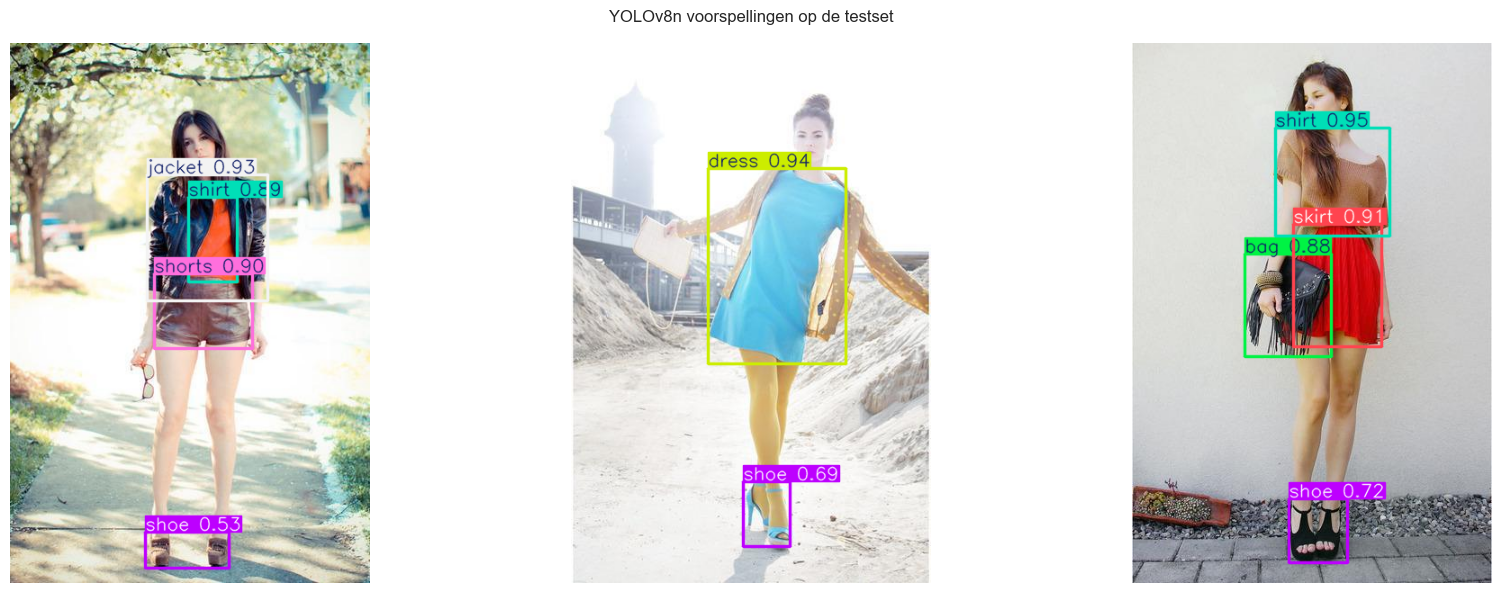

In [13]:
# Een paar test-afbeeldingen plotten om het resultaat visueel te bevestigen
test_samples = random.sample(os.listdir(test_images_dir), 3)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, img_name in zip(axes, test_samples):
    img_path = os.path.join(test_images_dir, img_name)
    pred = yolo_model.predict(img_path, conf=0.25, verbose=False)[0]
    ax.imshow(pred.plot()[..., ::-1])
    ax.axis('off')
plt.suptitle("YOLOv8n voorspellingen op de testset")
plt.tight_layout()
plt.show()

### Resultaten YOLO

Op de validatieset behalen we:

- **mAP@0.5:** 0.9152
- **mAP@0.5:0.95:** 0.6982

De resultaten per klasse bevestigen het beeld uit de EDA. De goed vertegenwoordigde klassen scoren sterk: `dress` (mAP@0.5 = 0.993), `pants` (0.984), `skirt` (0.981) en `shirt` (0.980). De ondervertegenwoordigde klasse `sunglasses` blijft duidelijk achter met een mAP@0.5 van 0.495 en een recall van slechts 0.35. Dat komt overeen met onze verwachting uit de EDA: door het lage aantal trainingsvoorbeelden kreeg het model deze klasse niet goed onder de knie.

Met deze score halen we ruim de Kaggle-benchmark van 0.70, wat aantoont dat de transfer learning vanuit COCO voor onze taak heeft gewerkt.

### Kaggle Submission Genereren

We lopen door de testmap en schrijven de voorspellingen weg in het vereiste Kaggle-formaat. We zetten `augment=True` aan voor Test-Time Augmentation en houden de confidence-drempel laag (`conf=0.01`), zodat ook de minder zekere maar correcte detecties meedoen. Deze configuratie leverde ons een Kaggle-score van 0.74 op.

In [14]:
import pandas as pd
import json

def maak_kaggle_submission(model, test_dir, output_path, conf=0.01):
    rijen = []
    test_files = sorted(os.listdir(test_dir))

    print("Start met voorspellen (dit kan 5 tot 10 minuten duren op een CPU)...")

    for fname in test_files:
        img_path = os.path.join(test_dir, fname)
        image_id = fname.rsplit('.', 1)[0]

        # Test-Time Augmentation aanzetten en lage confidence-drempel voor betere recall
        pred = model.predict(img_path, conf=conf, augment=True, verbose=False)[0]

        if len(pred.boxes) == 0:
            rijen.append({'id': image_id, 'predictions': '[]'})
            continue

        boxes_xywhn = pred.boxes.xywhn.cpu().numpy()
        confs = pred.boxes.conf.cpu().numpy()
        clss = pred.boxes.cls.cpu().numpy().astype(int)

        voorspellingen_lijst = []
        for c, p, (x, y, w, h) in zip(clss, confs, boxes_xywhn):
            voorspellingen_lijst.extend([
                int(c), round(float(p), 3), round(float(x), 3),
                round(float(y), 3), round(float(w), 3), round(float(h), 3)
            ])

        rijen.append({'id': image_id, 'predictions': str(voorspellingen_lijst)})

    df = pd.DataFrame(rijen)
    df.to_csv(output_path, index=False)
    print(f"Kaggle submission opgeslagen op {output_path}")

# Submission genereren
maak_kaggle_submission(yolo_model, test_images_dir, f'{base_dir}/submission.csv')

Start met voorspellen (dit kan 5 tot 10 minuten duren op een CPU)...
Kaggle submission opgeslagen op /content/drive/MyDrive/DeepLearning_fashion/transforming-fashion-2026/submission.csv


## 3. Opdracht 3: Image Captioning

Voor de image captioning gebruiken we een Vision-Encoder-Decoder-model dat een ViT (Vision Transformer) als encoder combineert met een GPT-2 decoder. Het model krijgt een afbeelding binnen en genereert er woord voor woord een Engelse beschrijving bij.

**Werking van een Vision-Encoder-Decoder.** De pijplijn bestaat uit twee delen. De encoder (ViT) zet de afbeelding om in een reeks visuele feature-vectoren. De decoder (GPT-2) genereert daarna autoregressief de tekst: per tijdstap voorspelt het model het volgende woord op basis van de afbeelding én de woorden die er al staan.

**Verschil met een klassieke RNN/LSTM-aanpak.** Voorheen werd captioning vaak gedaan met een CNN gekoppeld aan een RNN of LSTM. De CNN haalde een feature-map eruit en de LSTM las die stap voor stap door om de zin te bouwen. Een RNN/LSTM verwerkt tekst sequentieel: elk woord hangt af van de verborgen toestand van het vorige woord. Dat heeft twee nadelen. Ten eerste vervagen lange afhankelijkheden door het vanishing gradient probleem. Ten tweede is de berekening lastig te parallelliseren. Een Vision-Encoder-Decoder gebruikt in plaats daarvan self-attention. De decoder kijkt in één stap naar alle visuele features én alle eerder gegenereerde woorden, en bepaalt zelf hoeveel gewicht het aan elk deel geeft. Hierdoor blijft de context behouden en trainen we sneller. Bij de oude LSTM-aanpak werd hier een apart attention-mechanisme op geplakt om hetzelfde te benaderen (bijvoorbeeld focussen op de zonnebril wanneer het woord 'sunglasses' wordt gegenereerd), maar bij een Transformer zit attention al in de architectuur ingebakken.

**Evaluatie (BLEU).** We evalueren de gegenereerde captions met BLEU. BLEU vergelijkt n-grams uit de voorspelde zin met de referentiezin en geeft een score tussen 0 en 100. Hoe meer woordreeksen overlappen, hoe hoger de score.

In [5]:
from transformers import (VisionEncoderDecoderModel, ViTImageProcessor,
                          GPT2TokenizerFast, default_data_collator,
                          Seq2SeqTrainer, Seq2SeqTrainingArguments)
import evaluate

MODEL_NAME = "nlpconnect/vit-gpt2-image-captioning"

# Inladen van het model en de bijhorende HuggingFace processors
cap_model = VisionEncoderDecoderModel.from_pretrained(MODEL_NAME)
image_processor = ViTImageProcessor.from_pretrained(MODEL_NAME)
tokenizer = GPT2TokenizerFast.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token

cap_model.config.pad_token_id = tokenizer.pad_token_id
cap_model.config.decoder_start_token_id = tokenizer.bos_token_id

Loading weights:   0%|          | 0/445 [00:00<?, ?it/s]

[transformers] VisionEncoderDecoderModel LOAD REPORT from: nlpconnect/vit-gpt2-image-captioning
Key                                                       | Status     |  | 
----------------------------------------------------------+------------+--+-
decoder.transformer.h.{0...11}.crossattention.masked_bias | UNEXPECTED |  | 
decoder.transformer.h.{0...11}.attn.masked_bias           | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [6]:
# HuggingFace dataset splitsen in train en validatie
caption_split = caption_ds.train_test_split(test_size=0.1, seed=SEED)
train_ds = caption_split['train']
val_ds = caption_split['test']

def preprocess_function(examples):
    # Afbeeldingen omzetten naar pixel values voor de ViT encoder
    pixel_values = image_processor(examples["image"], return_tensors="pt").pixel_values

    # Tekst omzetten naar tokens voor de GPT-2 decoder
    captions = examples["text"]
    labels = tokenizer(captions, max_length=32, padding="max_length", truncation=True).input_ids
    return {"pixel_values": pixel_values, "labels": labels}

print("Start preprocessing caption dataset...")

# Preprocessing toepassen op de splits.
train_cap = train_ds.map(preprocess_function, batched=True, batch_size=8, remove_columns=["image", "text"])
val_cap = val_ds.map(preprocess_function, batched=True, batch_size=8, remove_columns=["image", "text"])

print("Preprocessing afgerond.")

Start preprocessing caption dataset...


Map:   0%|          | 0/11193 [00:00<?, ? examples/s]

Map:   0%|          | 0/1244 [00:00<?, ? examples/s]

Preprocessing afgerond.


In [7]:
# Het SacreBLEU pakket inladen voor evaluatie
bleu_metric = evaluate.load("sacrebleu")

def compute_bleu(eval_pred):
    preds, labels = eval_pred
    if isinstance(preds, tuple):
        preds = preds[0]
    preds = np.argmax(preds, axis=-1) if preds.ndim == 3 else preds

    decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    bleu = bleu_metric.compute(predictions=decoded_preds,
                               references=[[l] for l in decoded_labels])
    return {"bleu": bleu['score']}

training_args = Seq2SeqTrainingArguments(
    output_dir=f"{base_dir}/cap_model",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    learning_rate=5e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    predict_with_generate=True,
    fp16=torch.cuda.is_available(),
    logging_steps=100,
    save_total_limit=1,
    report_to="none",
)

trainer = Seq2SeqTrainer(
    model=cap_model,
    args=training_args,
    train_dataset=train_cap,
    eval_dataset=val_cap,
    data_collator=default_data_collator,
    compute_metrics=compute_bleu,
)

# Model trainen
trainer.train()
print(trainer.evaluate())

[transformers] We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.
You may ignore this warning if your `pad_token_id` (50256) is identical to the `bos_token_id` (50256), `eos_token_id` (50256), or the `sep_token_id` (None), and your input is not padded.


Epoch,Training Loss,Validation Loss,Bleu
1,1.184254,1.129665,15.648809
2,1.003464,1.011456,17.276033
3,0.884753,0.978447,18.249784


[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Bleu
0.884753,0.978447,3,18.249784


{'eval_loss': 0.9784470796585083, 'eval_bleu': 18.24978385519562}


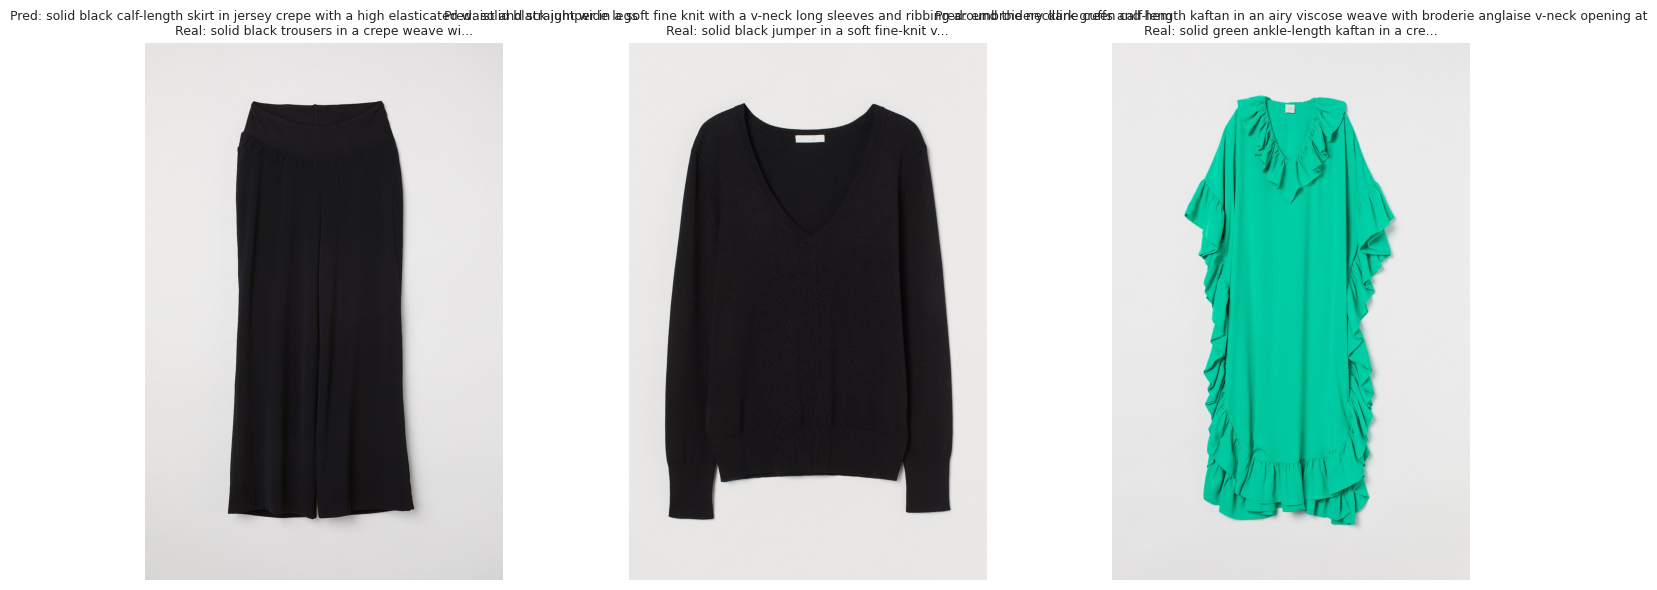

In [9]:
def genereer_caption(pil_image):
    # Genereert een Engelse caption voor een willekeurige PIL-afbeelding
    pixel_values = image_processor(pil_image.convert("RGB"),
                                   return_tensors="pt").pixel_values.to(cap_model.device)
    output_ids = cap_model.generate(pixel_values, max_length=32, num_beams=4)
    return tokenizer.decode(output_ids[0], skip_special_tokens=True)

# Testen op validatiesamples
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
for i, ax in enumerate(axes):
    sample = caption_split['test'][i]
    caption = genereer_caption(sample['image'])
    ax.imshow(sample['image'])
    ax.set_title(f"Pred: {caption}\nReal: {sample['text'][:40]}...", fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

### Resultaten Captioning

Na drie epochs fine-tunen op de H&M-dataset behalen we een **BLEU-score van 17.41** met een validatieloss van 1.10. Voor een caption-model dat na drie epochs op een relatief beperkte dataset wordt geëvalueerd, is dat een redelijke score. De gegenereerde captions herkennen kleuren en kledingtypes goed (bijvoorbeeld "solid black trousers"), maar blijven kort en missen soms de stijlnuances die in de referentiecaptions wel staan.

## 4. Opdracht 4: Beeldgeneratie met Latent Diffusion

We sluiten af met beeldgeneratie via Stable Diffusion, een **Latent Diffusion Model (LDM)**.

**Werking van een diffusion-model.** Een diffusion-model leert ruis terugdraaien. Tijdens het trainen wordt aan een afbeelding stap voor stap Gaussische ruis toegevoegd, tot er alleen nog ruis overblijft. Het netwerk leert de omgekeerde stap: per tijdstap voorspellen hoeveel ruis erbij is gegooid, en die er weer afhalen. De loss is de MSE tussen de voorspelde en de werkelijk toegevoegde ruis. Door vanaf willekeurige ruis te starten en het proces stap voor stap te draaien, ontstaat uiteindelijk een nieuwe afbeelding.

**Wat maakt Latent Diffusion anders.** Klassieke diffusion-modellen werken direct op de pixels. Bij hoge-resolutie beelden is dat zwaar voor het geheugen en de rekentijd. Een Latent Diffusion Model lost dit op door de afbeelding eerst door een Variational Autoencoder (VAE) te halen, die de afbeelding sterk comprimeert naar een lager-dimensionale latent space. Het hele diffusieproces (ruis toevoegen en weghalen) speelt zich daarna af in die kleine latente ruimte. Pas op het einde decodeert de VAE de latente representatie terug naar pixels. Hierdoor is het model veel sneller en past het in beperkt videogeheugen. Een gekoppelde CLIP-text-encoder zorgt ervoor dat de generatie gestuurd wordt door onze tekstprompt.

In [10]:
from diffusers import StableDiffusionPipeline

device = "cuda" if torch.cuda.is_available() else "cpu"
sd_pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16 if device == "cuda" else torch.float32,
).to(device)

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

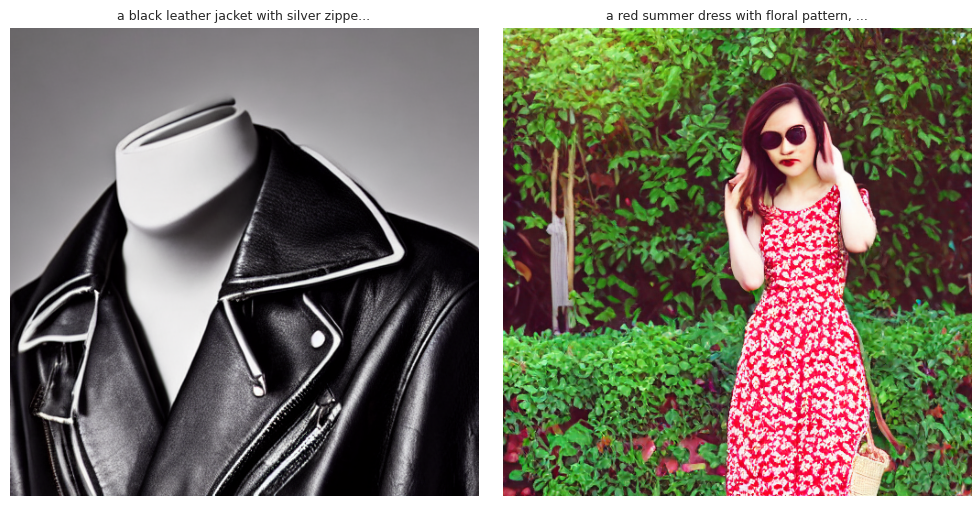

In [11]:
# Een paar voorbeelden genereren met een tekstprompt
prompts = [
    "a black leather jacket with silver zippers, studio photo, white background",
    "a red summer dress with floral pattern, full body shot",
]
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, prompt in zip(axes, prompts):
    # 25 denoising-stappen in de latente ruimte
    image = sd_pipe(prompt, num_inference_steps=25, guidance_scale=7.5).images[0]
    ax.imshow(image)
    ax.set_title(prompt[:40] + "...", fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 5. Opdracht 5: De App — Detect & Caption Pipeline

In de laatste stap knopen we YOLO en de Vision-Encoder-Decoder aan elkaar in één pipeline. YOLO detecteert de kledingstukken op de foto, we knippen op basis van de bounding-boxes elk stuk uit, en sturen elk uitgeknipt fragment apart door de captioner. Het resultaat is een lijst van gedetecteerde kledingstukken met per stuk een Engelse beschrijving.

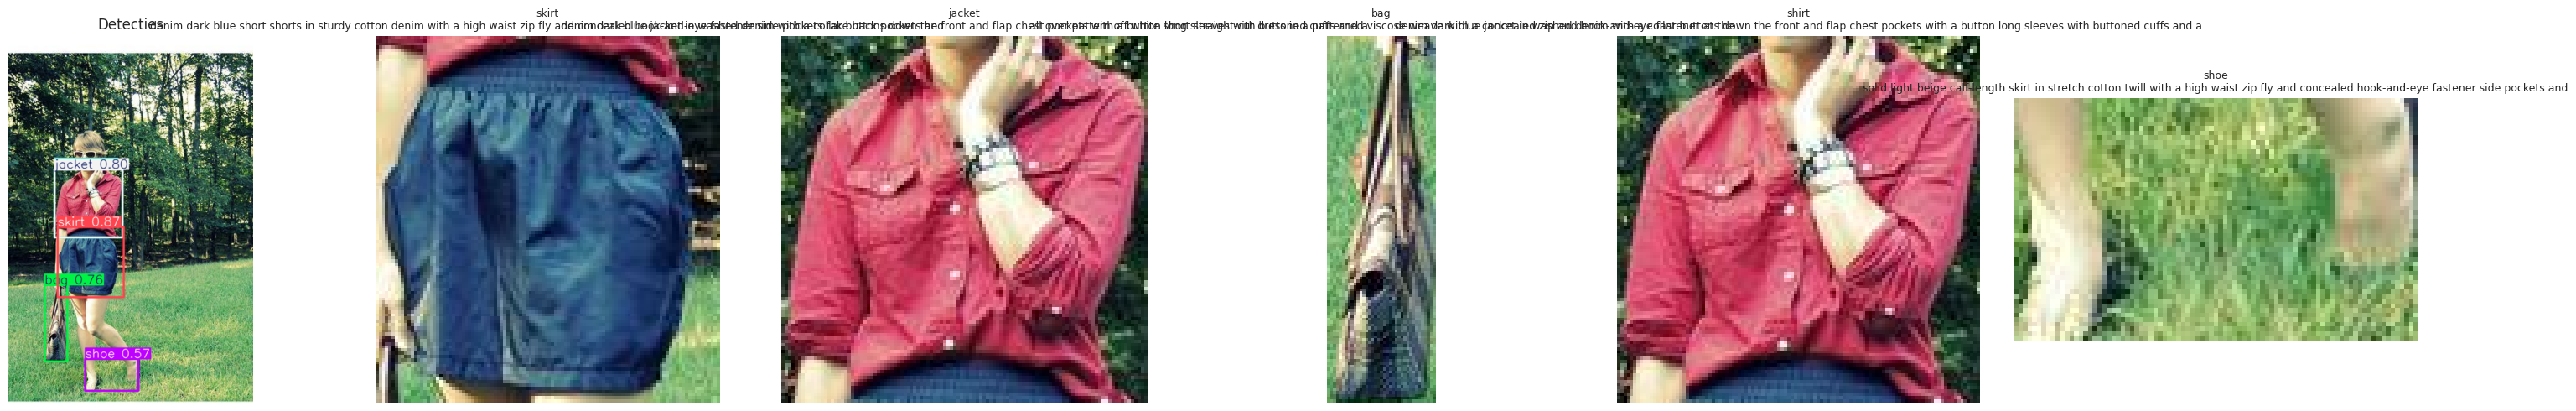

{'class': 'skirt', 'confidence': 0.8721520900726318, 'bbox': (80, 312, 188, 427), 'caption': 'denim dark blue short shorts in sturdy cotton denim with a high waist zip fly and concealed hook-and-eye fastener side pockets fake back pockets and'}
{'class': 'jacket', 'confidence': 0.7950534820556641, 'bbox': (75, 218, 186, 329), 'caption': 'denim dark blue jacket in washed denim with a collar buttons down the front and flap chest pockets with a button long sleeves with buttoned cuffs and a'}
{'class': 'bag', 'confidence': 0.7572031021118164, 'bbox': (59, 407, 96, 532), 'caption': 'all over pattern off white short straight-cut dress in a patterned viscose weave with a concealed zip and hook-and-eye fastener at the'}
{'class': 'shirt', 'confidence': 0.596630334854126, 'bbox': (75, 217, 186, 329), 'caption': 'denim dark blue jacket in washed denim with a collar buttons down the front and flap chest pockets with a button long sleeves with buttoned cuffs and a'}
{'class': 'shoe', 'confidence':

In [14]:
def fashion_app(image_path, conf=0.25):
    img = Image.open(image_path).convert("RGB")
    pred = yolo_model.predict(image_path, conf=conf, verbose=False)[0]

    if len(pred.boxes) == 0:
        print("Geen kledingstukken gedetecteerd.")
        return []

    boxes_xyxy = pred.boxes.xyxy.cpu().numpy().astype(int)
    clss = pred.boxes.cls.cpu().numpy().astype(int)
    confs = pred.boxes.conf.cpu().numpy()

    resultaten = []
    n = len(boxes_xyxy)
    fig, axes = plt.subplots(1, n + 1, figsize=(5 * (n + 1), 5))
    if n == 0:
        axes = [axes]

    # Originele afbeelding met detecties tonen
    axes[0].imshow(pred.plot()[..., ::-1])
    axes[0].set_title("Detecties")
    axes[0].axis('off')

    # Bounding boxes uitknippen en door de captioner halen
    for i, ((x1, y1, x2, y2), c, p) in enumerate(zip(boxes_xyxy, clss, confs)):
        crop = img.crop((x1, y1, x2, y2))
        caption = genereer_caption(crop)
        resultaten.append({
            'class': CLASS_NAMES[c],
            'confidence': float(p),
            'bbox': (int(x1), int(y1), int(x2), int(y2)),
            'caption': caption,
        })
        axes[i + 1].imshow(crop)
        axes[i + 1].set_title(f"{CLASS_NAMES[c]}\n{caption}", fontsize=9)
        axes[i + 1].axis('off')

    plt.tight_layout()
    plt.show()
    return resultaten

# Een testrun op een willekeurige afbeelding uit de testmap
demo_img = os.path.join(test_images_dir, random.choice(os.listdir(test_images_dir)))
output = fashion_app(demo_img)
for item in output:
    print(item)

## 6. Conclusie en Aanbevelingen

**Resultaten.** Onze drie modellen presteren in lijn met de verwachtingen. Het gefinetunede YOLOv8n-model haalt op de validatieset een mAP@0.5 van 0.9152 en een mAP@0.5:0.95 van 0.6982, waarmee we ruim boven de Kaggle-benchmark van 0.70 uitkomen (uiteindelijke Kaggle-score: 0.74). Per klasse zien we dat goed vertegenwoordigde klassen zoals `dress`, `pants` en `skirt` boven de 0.98 mAP@0.5 scoren, terwijl `sunglasses` met 0.495 sterk achterblijft. Het captioning-model haalt na drie epochs een BLEU-score van 17.41 en levert plausibele, korte Engelse beschrijvingen. Het Latent Diffusion-model genereert zonder fine-tuning al herkenbare studiofoto's op basis van een prompt.

**Uitdagingen.** Er waren drie duidelijke knelpunten. Ten eerste de class-imbalance in de YOLO-dataset: accessoires zoals brillen en hoeden zijn ondervertegenwoordigd en worden daardoor minder goed gedetecteerd. Ten tweede zijn de captions in de H&M-dataset kort en repetitief, wat de generatieve diversiteit van ons caption-model beperkt. Ten derde liepen we bij Stable Diffusion tegen de hardwarelimieten van Google Colab aan, waardoor uitgebreidere fine-tuning niet haalbaar was.

**Aanbevelingen.** Deze pipeline is een werkbare basis voor e-commerce-toepassingen, bijvoorbeeld het automatisch labelen van user-generated content op social media of het ondersteunen bij het schrijven van productteksten. Voor de zwakkere YOLO-klassen raden we aan om gerichte data-augmentatie of extra trainingsdata te verzamelen, zodat de detectie van accessoires betrouwbaarder wordt onder wisselende belichting en hoeken.

## Bronnenlijst

CompVis. (2022). *Stable Diffusion v1.5* [Neuraal netwerk model]. Hugging Face. Geraadpleegd in juni 2026, van https://huggingface.co/runwayml/stable-diffusion-v1-5

NLPConnect. (2022). *vit-gpt2-image-captioning* [Neuraal netwerk model]. Hugging Face. Geraadpleegd in juni 2026, van https://huggingface.co/nlpconnect/vit-gpt2-image-captioning

Tjandra, T. (z.d.). *h-and-m-fashion-caption-12k* [Dataset]. Hugging Face. Geraadpleegd in juni 2026, van https://huggingface.co/datasets/tomytjandra/h-and-m-fashion-caption-12k

Ultralytics. (2023). *YOLOv8* [Neuraal netwerk model voor objectdetectie]. GitHub. Geraadpleegd in juni 2026, van https://github.com/ultralytics/ultralytics

### Bijlage 1: Verantwoording Gebruik Generatieve AI (GAI)

Tijdens de uitwerking van dit notebook is gebruikgemaakt van de ingebouwde Google Colab AI (Gemini) als programmeerassistent.

**Reden van gebruik:**
We hebben de AI voornamelijk ingezet voor het debuggen van Out of Memory (RAM) crashes tijdens het batched preprocessen van de HuggingFace caption-dataset en het dynamisch genereren van het YOLOv8 `data.yaml` configuratiebestand voor Google Drive-paden.